# Demand-Response Style Exploration

Guide-like notebook that mirrors the Kaggle demand-response visuals using the Building Data Genome Project 2 dataset. Each section explains the goal before the code/plots.


In [ ]:
# Imports + plotting defaults
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

DATA_PATH = Path('example_data/building_data_genome_project_2')


## 1. Load metadata & weather
We start by loading metadata (building types, areas) and weather (outdoor conditions) that will be needed for baseline and pseudo demand-response analyses.


In [ ]:
metadata = pd.read_csv(DATA_PATH / 'metadata.csv')
metadata['primaryspaceusage'] = metadata['primaryspaceusage'].str.strip()
weather = pd.read_csv(DATA_PATH / 'weather.csv')
weather['timestamp'] = pd.to_datetime(weather['timestamp'])
print(f"Metadata rows: {len(metadata)} | Weather rows: {len(weather)}")
print("Unique site IDs with weather:", weather['site_id'].nunique())


Metadata rows: 1636 | Weather rows: 331166
Unique site IDs with weather: 19


## 2. Load meter data (all fuels)
We’ll need electricity plus other meter types (steam, chilled water, etc.) to see how multiple loads respond during “events”. This cell loads every cleaned meter file and computes per-square-foot intensities for fair comparisons.


In [ ]:
MEASUREMENT_FILES = {
    'electricity_kwh': DATA_PATH / 'electricity_cleaned.csv',
    'hotwater': DATA_PATH / 'hotwater_cleaned.csv',
    'chilledwater': DATA_PATH / 'chilledwater_cleaned.csv',
    'steam': DATA_PATH / 'steam_cleaned.csv',
    'water': DATA_PATH / 'water_cleaned.csv',
    'irrigation': DATA_PATH / 'irrigation_cleaned.csv',
    'solar': DATA_PATH / 'solar_cleaned.csv',
    'gas': DATA_PATH / 'gas_cleaned.csv',
}

_measurement_cache = {}
_intensity_cache = {}


def load_measurement(name: str) -> pd.DataFrame:
    if name not in _measurement_cache:
        df = pd.read_csv(MEASUREMENT_FILES[name])
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        _measurement_cache[name] = df
    return _measurement_cache[name]


def load_intensity(name: str) -> pd.DataFrame:
    if name not in _intensity_cache:
        df = load_measurement(name)
        cols = [c for c in df.columns if c != 'timestamp']
        areas = metadata.set_index('building_id').loc[cols, 'sqft']
        intensity = df[cols].astype(float).div(areas.values, axis=1)
        intensity.insert(0, 'timestamp', df['timestamp'])
        _intensity_cache[name] = intensity
    return _intensity_cache[name]

# Load electricity intensities as baseline
electricity_intensity = load_intensity('electricity_kwh')
print(f"Electricity intensity shape: {electricity_intensity.shape}")


Electricity intensity shape: (17544, 1579)


## 3. Cohort selection & helper functions
We’ll focus on lodging/residential buildings (matching the Kaggle example). The helper below aggregates meters by cohort/site and assembles weather-aligned series for later plots.


In [ ]:
lodging_buildings = metadata[metadata['primaryspaceusage'].str.lower() == 'lodging/residential']['building_id'].tolist()


def aggregate_cohort(intensity_df: pd.DataFrame, label: str) -> pd.DataFrame:
    cols = [c for c in lodging_buildings if c in intensity_df.columns]
    data = intensity_df[['timestamp'] + cols].copy()
    data[label] = data[cols].mean(axis=1)
    return data[['timestamp', label]]

cohort_power = aggregate_cohort(electricity_intensity, 'electricity_kwh_sqft')
print(f"Cohort series: {cohort_power.shape}")


Cohort series: (17544, 2)


In [ ]:
weather_cohort = weather[weather['site_id'].isin(metadata[metadata['building_id'].isin(lodging_buildings)]['site_id'])].copy()
weather_cohort = weather_cohort.groupby('timestamp')[['airTemperature', 'dewTemperature', 'windSpeed', 'cloudCoverage']].mean().reset_index()
weather_cohort = weather_cohort.rename(columns={'airTemperature': 'cohort_airTemperature'})


In [ ]:
cohort_df = cohort_power.merge(weather_cohort, on='timestamp', how='left')
cohort_df = cohort_df.sort_values('timestamp').reset_index(drop=True)
cohort_df['date'] = cohort_df['timestamp'].dt.date
cohort_df['hour'] = cohort_df['timestamp'].dt.hour
cohort_df['dayofweek'] = cohort_df['timestamp'].dt.dayofweek
cohort_df['is_weekend'] = cohort_df['dayofweek'] >= 5
print(cohort_df.head())


            timestamp  electricity_kwh_sqft  cohort_airTemperature  \
0 2016-01-01 00:00:00              0.000784               4.109091   
1 2016-01-01 01:00:00              0.000799               4.316667   
2 2016-01-01 02:00:00              0.000798               3.550000   
3 2016-01-01 03:00:00              0.000787               3.491667   
4 2016-01-01 04:00:00              0.000796               3.225000   

   dewTemperature  windSpeed  cloudCoverage        date  hour  dayofweek  \
0       -0.690909   2.709091       1.600000  2016-01-01     0          4   
1       -0.691667   2.325000       1.555556  2016-01-01     1          4   
2       -0.950000   1.675000       0.000000  2016-01-01     2          4   
3       -1.216667   2.266667       0.000000  2016-01-01     3          4   
4       -1.566667   2.566667       0.750000  2016-01-01     4          4   

   is_weekend  
0       False  
1       False  
2       False  
3       False  
4       False  


In [ ]:
def explain(text):
    display(Markdown(text))


## 4. Baseline percentile ribbon (Kaggle-style)
Replicates the Kaggle demand-response ribbon plot: every day’s hourly profile is grey, percentile bands are dashed, and weekday/weekend averages are highlighted.


**Percentile ribbon** – visual baseline for the residential cohort. Grey lines = individual days, dashed = percentiles, colored lines = weekday/weekend averages.

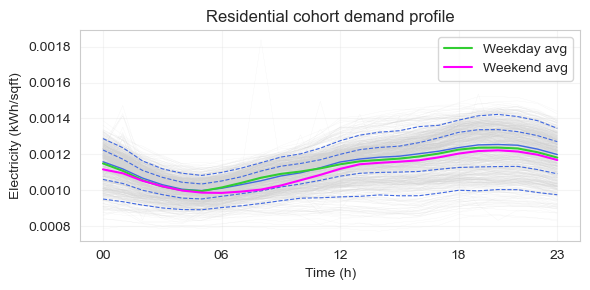

In [ ]:
def plot_percentile_ribbon(df: pd.DataFrame):
    explain("**Percentile ribbon** – visual baseline for the residential cohort. Grey lines = individual days, dashed = percentiles, colored lines = weekday/weekend averages.")
    df = df.copy()
    df['date'] = df['timestamp'].dt.date
    df['time'] = df['timestamp'].dt.time
    df['hour'] = df['timestamp'].dt.hour
    df['is_weekend'] = df['timestamp'].dt.dayofweek >= 5

    pivot = df.pivot_table(index='date', columns='hour', values='electricity_kwh_sqft')
    percentiles = pivot.quantile([0.05, 0.25, 0.5, 0.75, 0.95])

    weekday_mean = df[df['is_weekend'] == False].groupby('hour')['electricity_kwh_sqft'].mean()
    weekend_mean = df[df['is_weekend'] == True].groupby('hour')['electricity_kwh_sqft'].mean()

    hours = range(24)
    fig, ax = plt.subplots(figsize=(6, 3))
    for _, row in pivot.iterrows():
        ax.plot(hours, row, color='lightgrey', linewidth=0.1, alpha=0.6)
    for q in [0.05, 0.25, 0.75, 0.95]:
        ax.plot(hours, percentiles.loc[q], color='royalblue', linestyle='--', linewidth=0.8)
    ax.plot(hours, percentiles.loc[0.5], color='royalblue', linewidth=1)
    ax.plot(hours, weekday_mean, color='limegreen', linewidth=1.5, label='Weekday avg')
    ax.plot(hours, weekend_mean, color='magenta', linewidth=1.5, label='Weekend avg')
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_xticklabels(['00', '06', '12', '18', '23'])
    ax.set_ylabel('Electricity (kWh/sqft)')
    ax.set_xlabel('Time (h)')
    ax.legend()
    ax.set_title('Residential cohort demand profile')
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_percentile_ribbon(cohort_df)


## 5. Rolling demand vs. weather overlay
See how cohort load tracks temperature through the year (7-day mean). Makes it easy to spot periods that would trigger a DR call.


**Rolling overlay** – 7-day moving averages of load and temperature.

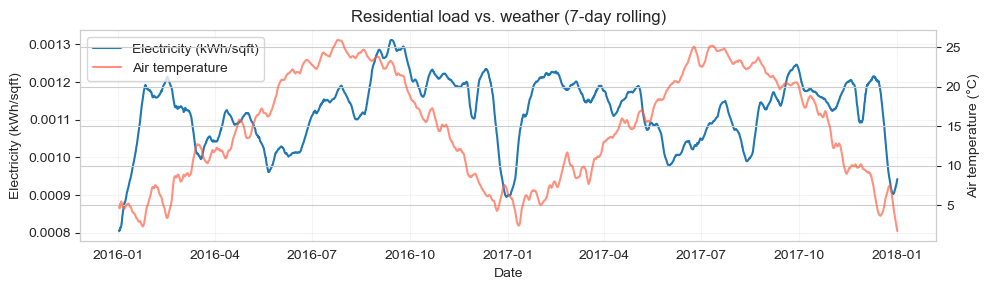

In [ ]:
overlay = cohort_df[['timestamp', 'electricity_kwh_sqft', 'cohort_airTemperature']].set_index('timestamp').sort_index()
overlay = overlay.rolling(window=24 * 7, min_periods=24).mean()
explain("**Rolling overlay** – 7-day moving averages of load and temperature.")
fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.plot(overlay.index, overlay['electricity_kwh_sqft'], color='tab:blue', label='Electricity (kWh/sqft)')
ax1.set_ylabel('Electricity (kWh/sqft)')
ax1.set_xlabel('Date')
ax1.grid(alpha=0.2)
ax2 = ax1.twinx()
ax2.plot(overlay.index, overlay['cohort_airTemperature'], color='tomato', alpha=0.7, label='Air temperature')
ax2.set_ylabel('Air temperature (°C)')
plt.title('Residential load vs. weather (7-day rolling)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()


## 6. Heat-event vs. baseline demand
Treat the hottest hours (top 5% temperature) as pseudo DR events. Compare their hourly profile to the baseline to see how much extra load appears during those stress periods.


**Heat-event profile** – 68 hottest days vs 595 cool days.

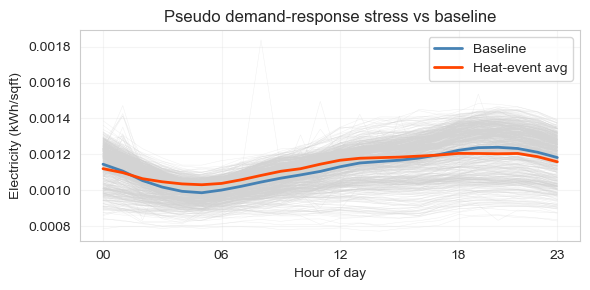

In [ ]:
threshold = cohort_df['cohort_airTemperature'].quantile(0.95)
cohort_df['is_heat_event'] = cohort_df['cohort_airTemperature'] >= threshold

heat_days = cohort_df.groupby('date')['is_heat_event'].mean()
heat_event_dates = heat_days[heat_days > 0.25].index  # days with ≥25% hot hours
baseline_dates = heat_days[heat_days <= 0.05].index

pivot = cohort_df.pivot_table(index='date', columns='hour', values='electricity_kwh_sqft')
heat_profiles = pivot.loc[heat_event_dates].dropna(how='all')
baseline_profiles = pivot.loc[baseline_dates].dropna(how='all')
heat_mean = heat_profiles.mean(axis=0)
baseline_mean = baseline_profiles.mean(axis=0)

explain(f"**Heat-event profile** – {len(heat_event_dates)} hottest days vs {len(baseline_dates)} cool days.")
fig, ax = plt.subplots(figsize=(6, 3))
for _, row in baseline_profiles.iterrows():
    ax.plot(row.index, row.values, color='lightgrey', linewidth=0.3, alpha=0.4)
ax.plot(baseline_mean.index, baseline_mean.values, color='steelblue', linewidth=2, label='Baseline')
ax.plot(heat_mean.index, heat_mean.values, color='orangered', linewidth=2, label='Heat-event avg')
ax.fill_between(heat_mean.index, baseline_mean.values, heat_mean.values, color='orangered', alpha=0.2)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Electricity (kWh/sqft)')
ax.set_xticks([0, 6, 12, 18, 23])
ax.set_xticklabels(['00', '06', '12', '18', '23'])
ax.set_title('Pseudo demand-response stress vs baseline')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 7. Multi-meter response during heat events
See whether other loads (water, steam, chilled water) move in sync with electricity during the same extreme periods.


**Meter comparison** – average intensity during heat events vs baseline.

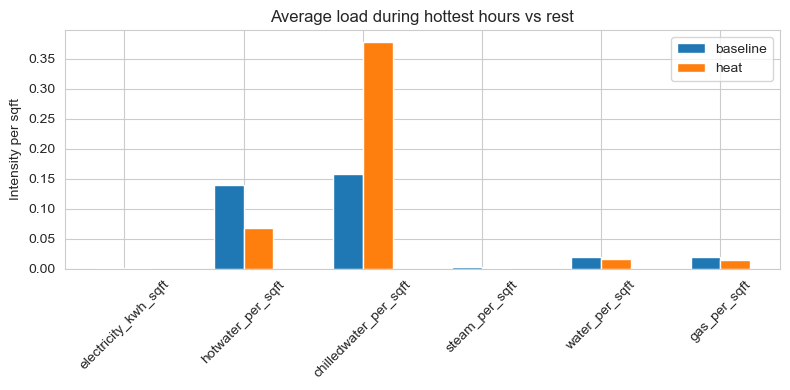

In [ ]:
extra_meters = ['hotwater', 'chilledwater', 'steam', 'water', 'gas']
extra_series = {}
for meter in extra_meters:
    try:
        intensity = load_intensity(meter)
        extra_series[meter] = aggregate_cohort(intensity, f'{meter}_per_sqft')
    except KeyError:
        continue

combined = cohort_df[['timestamp', 'electricity_kwh_sqft', 'is_heat_event']].copy()
for meter, series in extra_series.items():
    combined = combined.merge(series, on='timestamp', how='left')

heat_avg = combined[combined['is_heat_event']].mean(numeric_only=True)
base_avg = combined[~combined['is_heat_event']].mean(numeric_only=True)
metric_names = [col for col in combined.columns if col.endswith('per_sqft') or col == 'electricity_kwh_sqft']

explain("**Meter comparison** – average intensity during heat events vs baseline.")
vals = pd.DataFrame({'baseline': base_avg[metric_names], 'heat': heat_avg[metric_names]})
vals.plot(kind='bar', figsize=(8, 4))
plt.ylabel('Intensity per sqft')
plt.title('Average load during hottest hours vs rest')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Event-day actual vs baseline
For the hottest day in the record, compare actual hourly demand to a rolling baseline (7-day median) to mimic “expected vs DR target” plots.


**Event day 2017-08-22** – actual vs rolling baseline

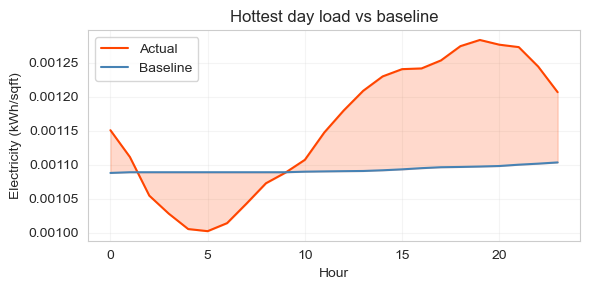

In [ ]:
cohort_df = cohort_df.sort_values('timestamp').reset_index(drop=True)
cohort_df['baseline'] = cohort_df['electricity_kwh_sqft'].rolling(window=24 * 7, min_periods=24).median()
heat_day = heat_event_dates[-1] if len(heat_event_dates) else cohort_df['date'].iloc[0]
day_data = cohort_df[cohort_df['date'] == heat_day]
explain(f"**Event day {heat_day}** – actual vs rolling baseline")
plt.figure(figsize=(6, 3))
plt.plot(day_data['hour'], day_data['electricity_kwh_sqft'], label='Actual', color='orangered')
plt.plot(day_data['hour'], day_data['baseline'], label='Baseline', color='steelblue')
plt.fill_between(day_data['hour'], day_data['baseline'], day_data['electricity_kwh_sqft'], color='orangered', alpha=0.2)
plt.xlabel('Hour')
plt.ylabel('Electricity (kWh/sqft)')
plt.title('Hottest day load vs baseline')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 9. Next steps
- Repeat the same visuals for other building types (office, education) by changing the `lodging_buildings` filter.
- Overlay actual DR event markers (if available) by replacing the heat-event heuristics with true signals.
- Feed the event/baseline features into a small predictive model to quantify achievable shed amounts.

This notebook should now serve as a narrative walkthrough for demand-response style EDA on BDG2.
